# Lesson 15 - Physics-structured networks: Hamiltonian neural networks and neural ODEs.


Questions this lesson answers
-----------------------------
* How can we build a physical law (energy conservation) into a network instead of hoping
  it learns it? (Learn the scalar Hamiltonian, differentiate it with autograd.)
* Why do small errors in a learnt vector field ruin long simulations, and how does
  structure fix that?
* How can we learn a continuous-time model directly from irregularly sampled
  trajectories? (Neural ODE: back-propagate through an ODE solver.)

Script version:  python lessons/15_hamiltonian_neural_ode/lesson.py

## Lesson 15 - Physics-structured networks: Hamiltonian neural networks and neural ODEs

📄 [`lessons/15_hamiltonian_neural_ode/lesson.py`](../lessons/15_hamiltonian_neural_ode/lesson.py) · 📓 [`notebooks/15_hamiltonian_neural_ode.ipynb`](15_hamiltonian_neural_ode.ipynb) · code: [`nnaz/physics_nets.py`](../nnaz/physics_nets.py)

### Hamiltonian neural networks

A frictionless mechanical system is described by one scalar, the energy $H(q,p)$, through
Hamilton's equations $\dot q=\partial H/\partial p,\ \dot p=-\partial H/\partial q$. Two ways to
learn the pendulum ($H=p^2/2+1-\cos q$) from 50 noisy trajectories:

* **baseline**: an MLP maps $(q,p)\mapsto(\dot q,\dot p)$. It can represent *any* vector field,
  including ones that slowly gain or lose energy;
* **HNN** (Greydanus et al., 2019): an MLP outputs the scalar $H_\theta(q,p)$. The vector field is
  its **symplectic gradient**, computed by autograd: $(\partial_pH_\theta,-\partial_qH_\theta)$.
  Along this field $\dot H_\theta=\partial_qH_\theta\,\dot q+\partial_pH_\theta\,\dot p=0$
  **identically**. Energy conservation is built in, not learnt.

Both fields are integrated with the same RK4 scheme for 100 time units (about 15 periods) from
unseen initial states.

<p align="center"><img src="../docs/lesson15/hnn_pendulum.png" width="100%"><br><img src="../docs/lesson15/pendulums.gif" width="40%"></p>

### Neural ODEs

A **neural ODE** (Chen et al., 2018) models $\dot x=f_\theta(x)$ and is fitted to *trajectory
samples*, with no derivatives needed. We integrate the ODE with a differentiable RK4 solver and
backpropagate through the solver steps. Here the data are **120 irregularly timed**, noisy
observations of the Lotka-Volterra predator-prey system
($\dot u=au-buv,\ \dot v=-cv+duv$). A continuous-time model handles irregular sampling
naturally. We use **multiple shooting**: short windows, each started from an observed state,
which keeps the gradients well-behaved. The model works in log-populations for positivity. The
baseline is the best **linear** ODE $\dot z=Az+b$ in log space, fitted by least squares to finite
differences.

<p align="center"><img src="../docs/lesson15/neural_ode_lv.png" width="100%"></p>

*(see the results table in the README)*

**Reading the numbers.**
* The plain MLP's small vector-field errors accumulate. Over 15 periods the true energy of its
  rollouts changes by 11-48 %: the pendulum slowly speeds up or dies out.
* The HNN changes it by only 1-2 %. What it conserves exactly is its *learnt* energy $H_\theta$,
  which differs slightly from the true $H$. The level-set plot shows how close they are.
* Conservation does **not** guarantee phase accuracy. For one start the HNN's state error is
  slightly larger than the baseline's, because a small error in the period accumulates as a
  phase shift. Structure removes a whole class of errors (drift in energy), not all errors.
* The neural ODE, trained only on 120 noisy, irregularly timed samples, tracks the true
  trajectory and extrapolates to twice the training window with a log-error below 0.08. It nearly
  conserves the Lotka-Volterra invariant, even though nothing forces it to (it has no built-in
  structure, unlike the HNN). The best linear ODE cannot represent the nonlinear predator-prey
  coupling at all.



In [1]:
%matplotlib inline
import sys, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # make `nnaz` importable
from nnaz.notebooks import show_new_figures

from __future__ import annotations
import sys
from pathlib import Path
import numpy as np
import torch
from nnaz.common import banner, save_gif, save_results, savefig, seed_everything, set_torch_threads, setup_matplotlib
from nnaz.physics_nets import (HNN, LV, Baseline, ODEFunc, lotka_volterra, lv_data, model_field_np, odeint_rk4,
                               pendulum_H, pendulum_data, pendulum_field, rk4, train_field, train_neural_ode)
LESSON = 15
plt = setup_matplotlib()

## 1. The pendulum: a plain MLP vector field vs a Hamiltonian neural network

In [2]:
def hnn_part(rng, quick):
    banner("1. The pendulum: a plain MLP vector field vs a Hamiltonian neural network")
    X, dX = pendulum_data(25 if quick else 50, rng)
    print(f"  {len(X)} noisy (state, derivative) samples from 50 trajectories (noise std 0.05)")
    models = {"baseline MLP": Baseline(), "HNN": HNN()}
    for name, m in models.items():
        torch.manual_seed(0)
        m.apply(lambda mod: mod.reset_parameters() if hasattr(mod, "reset_parameters") else None)
        train_field(m, X, dX, steps=500 if quick else 4000)
    # long rollouts from unseen initial conditions, same RK4 integrator for everyone
    dt, n = 0.1, 1000   # 100 time units ~ 15 periods
    starts = [np.array([1.2, 0.0]), np.array([0.0, 1.0]), np.array([-2.0, 0.3])]
    res, trajs = {}, {}
    for name, f in [("exact", pendulum_field)] + [(k, model_field_np(m)) for k, m in models.items()]:
        tr = [np.array(rk4(f, x0, dt, n)) for x0 in starts]
        trajs[name] = tr
    for name in models:
        drift = [float(np.abs(pendulum_H(*t[-1]) - pendulum_H(*t[0])) / pendulum_H(*t[0])) for t in trajs[name]]
        err = [float(np.sqrt(((t - e) ** 2).sum(1)).mean()) for t, e in zip(trajs[name], trajs["exact"])]
        res[name] = dict(energy_drift_rel=drift, traj_err=err)
        print(f"  {name:13s} relative energy change after 100 time units: "
              + ", ".join(f"{d:.3f}" for d in drift) + " | mean state error " + ", ".join(f"{e:.3f}" for e in err))
    ex_drift = [float(abs(pendulum_H(*t[-1]) - pendulum_H(*t[0])) / pendulum_H(*t[0])) for t in trajs["exact"]]
    res["exact field + RK4 (integrator error only)"] = dict(energy_drift_rel=ex_drift)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
    k = 0
    tt = np.arange(n + 1) * dt
    for name, style in [("exact", "k-"), ("baseline MLP", "C0-"), ("HNN", "C1--")]:
        t = trajs[name][k]
        axs[0].plot(t[:, 0], t[:, 1], style, lw=1, label=name)
        axs[1].plot(tt, pendulum_H(t[:, 0], t[:, 1]), style, label=name)
    axs[0].set_xlabel("q"); axs[0].set_ylabel("p"); axs[0].set_title("phase space, 100 time units"); axs[0].legend()
    axs[1].set_xlabel("t"); axs[1].set_ylabel("true energy H(q, p)"); axs[1].set_title("energy along the rollout")
    qq, pp = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-2.5, 2.5, 100))
    with torch.no_grad():
        Hl = models["HNN"].H(torch.as_tensor(np.c_[qq.ravel(), pp.ravel()], dtype=torch.float32)).numpy().reshape(qq.shape)
    Ht = pendulum_H(qq, pp)
    Hl = Hl - Hl[50, 50] + Ht[50, 50]   # H is defined up to a constant
    cs = axs[2].contour(qq, pp, Ht, levels=10, colors="k", linewidths=0.8)
    axs[2].contour(qq, pp, Hl, levels=cs.levels, colors="C1", linestyles="--", linewidths=1)
    axs[2].scatter(X[::10, 0], X[::10, 1], s=1, c="0.7")
    axs[2].set_title("level sets: true H (black) vs learnt H (orange)"); axs[2].set_xlabel("q")
    savefig(fig, LESSON, "hnn_pendulum.png")

    from matplotlib.animation import FuncAnimation

    fig, ax = plt.subplots(figsize=(4.6, 3.2))
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 0.4); ax.set_aspect("equal"); ax.grid(False)
    rods = {name: ax.plot([], [], "o-", lw=2, ms=8, color=c, label=name, alpha=a)[0]
            for name, c, a in [("exact", "k", 0.35), ("baseline MLP", "C0", 0.9), ("HNN", "C1", 0.9)]}
    ax.legend(fontsize=7, loc="lower right"); ttl = ax.set_title("")

    def draw(f):
        i = 700 + 2 * f   # late times, where drift shows
        for name, rod in rods.items():
            q = trajs[name][0][i, 0]
            rod.set_data([0, np.sin(q)], [0, -np.cos(q)])
        ttl.set_text(f"t = {i * dt:.1f}")
        return list(rods.values())

    save_gif(FuncAnimation(fig, draw, frames=150), LESSON, "pendulums.gif", fps=15)
    return {"hnn": res}

## 2. A neural ODE learnt from irregularly sampled Lotka-Volterra data

In [3]:
def neural_ode_part(rng, quick):
    banner("2. A neural ODE learnt from irregularly sampled Lotka-Volterra data")
    t, y, clean = lv_data(rng)
    print(f"  {len(t)} observations at random times in [0, 30], 2 % noise")
    torch.manual_seed(0)
    func = ODEFunc()
    hist, tt = train_neural_ode(func, t, y, steps=150 if quick else 1500, log=500 if not quick else 0)
    # baseline: best LINEAR ODE dz/dt = A z + b in log-space, from finite differences (least squares)
    Z = np.log(y)
    dZ = np.diff(Z, axis=0) / np.diff(t)[:, None]
    M = np.c_[Z[:-1], np.ones(len(Z) - 1)]
    coef = np.linalg.lstsq(M, dZ, rcond=None)[0]
    lin = lambda z: np.c_[z.reshape(-1, 2), np.ones(z.reshape(-1, 2).shape[0])] @ coef
    # evaluate on a fine grid out to t = 60 (twice the training window) from the true initial state
    tg = np.linspace(0, 60, 1201)
    from scipy.integrate import solve_ivp
    exact = solve_ivp(lambda _, x: lotka_volterra(x), (0, 60), [10.0, 5.0], t_eval=tg, rtol=1e-10, atol=1e-10).y.T
    with torch.no_grad():
        node = torch.exp(odeint_rk4(func, torch.log(torch.tensor([10.0, 5.0])), torch.as_tensor(tg, dtype=torch.float32),
                                    substeps=1)).numpy()
    linz = np.exp(np.array(rk4(lambda z: lin(z).reshape(z.shape), np.log([10.0, 5.0]), tg[1] - tg[0], len(tg) - 1)))

    def V(x):  # the conserved quantity of Lotka-Volterra
        u, v = x[:, 0], x[:, 1]
        return LV["d"] * u - LV["c"] * np.log(u) + LV["b"] * v - LV["a"] * np.log(v)

    res = {}
    for name, traj in [("neural ODE", node), ("linear ODE in log-space", linz)]:
        inside, outside = tg <= 30, tg > 30
        e_in = float(np.sqrt(np.mean((np.log(traj[inside]) - np.log(exact[inside])) ** 2)))
        e_out = float(np.sqrt(np.mean((np.log(traj[outside]) - np.log(exact[outside])) ** 2)))
        dV = float(np.abs(V(traj) - V(exact[:1])).max())
        res[name] = dict(log_rmse_train_window=e_in, log_rmse_extrapolation=e_out, max_invariant_change=dV)
        print(f"  {name:24s} log-RMSE on [0,30] {e_in:.3f}, extrapolation (30,60] {e_out:.3f};"
              f" max change of the LV invariant {dV:.3f}")
    fig, axs = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [2, 1]})
    for i, (lab, c) in enumerate([("prey", "C2"), ("predator", "C3")]):
        axs[0].plot(tg, exact[:, i], color=c, lw=3, alpha=0.35, label=f"{lab} exact")
        axs[0].plot(tg, node[:, i], "--", color=c, label=f"{lab} neural ODE")
        axs[0].plot(t, y[:, i], ".", color=c, ms=4)
    axs[0].plot(tg, linz[:, 0], ":", color="0.4", label="linear ODE (prey)")
    axs[0].axvspan(30, 60, color="0.93", zorder=0); axs[0].text(31, axs[0].get_ylim()[1] * 0.9, "extrapolation", fontsize=8)
    axs[0].set_xlabel("t"); axs[0].legend(fontsize=7, ncol=3); axs[0].set_title("dots: irregular noisy training data")
    axs[1].plot(exact[:, 0], exact[:, 1], "k", lw=3, alpha=0.35, label="exact")
    axs[1].plot(node[:, 0], node[:, 1], "C1--", label="neural ODE")
    axs[1].set_xlabel("prey"); axs[1].set_ylabel("predator"); axs[1].legend(fontsize=8); axs[1].set_title("phase plane")
    savefig(fig, LESSON, "neural_ode_lv.png")
    res["train_s"] = tt
    return {"neural_ode": res}

## Run the lesson

Set `quick = True` for a fast pass (fewer epochs; numbers will differ from the README).

In [4]:
quick = False

In [5]:
rng = seed_everything(15)

In [6]:
set_torch_threads()


1. The pendulum: a plain MLP vector field vs a Hamiltonian neural network


  5000 noisy (state, derivative) samples from 50 trajectories (noise std 0.05)


  baseline MLP  relative energy change after 100 time units: 0.122, 0.106, 0.484 | mean state error 0.129, 0.188, 2.297
  HNN           relative energy change after 100 time units: 0.021, 0.020, 0.009 | mean state error 0.159, 0.123, 0.019


  saved docs/lesson15/hnn_pendulum.png


  saved docs/lesson15/pendulums.gif


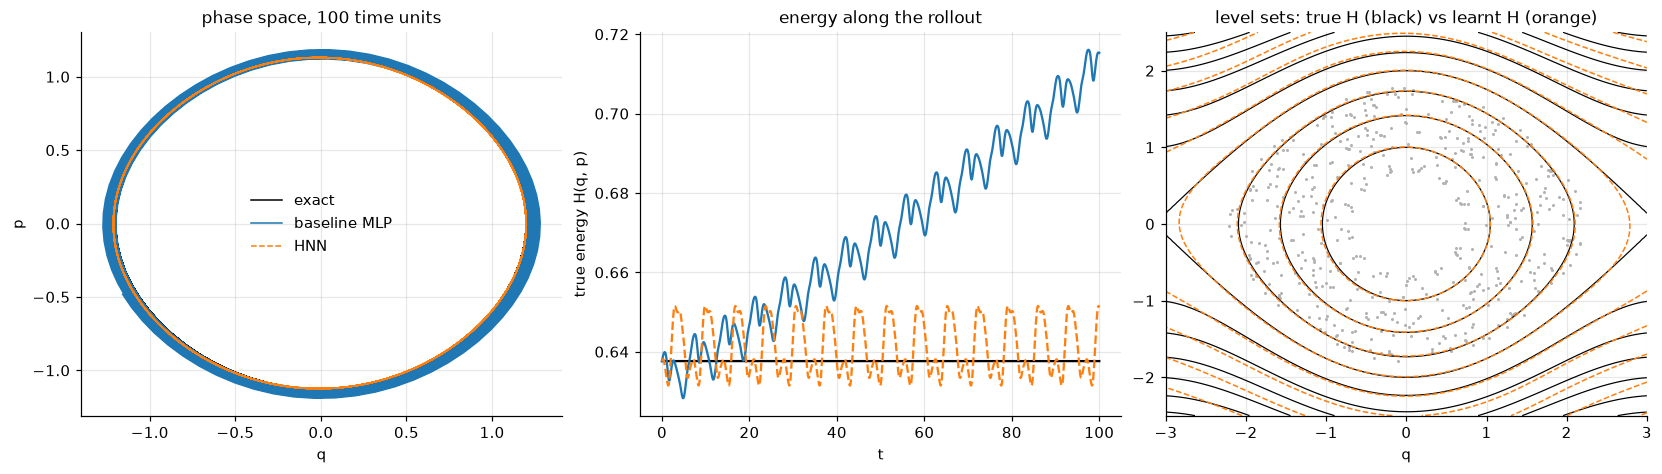

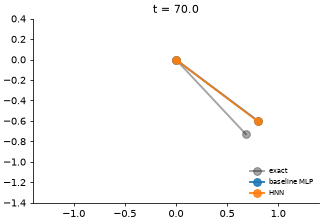

In [7]:
t0 = time.time()
res = hnn_part(rng, quick)
show_new_figures(t0, LESSON)


2. A neural ODE learnt from irregularly sampled Lotka-Volterra data
  120 observations at random times in [0, 30], 2 % noise


    step   500  loss 1.37e-02  (13s)


    step  1000  loss 1.10e-03  (26s)


    step  1500  loss 8.12e-04  (39s)


  neural ODE               log-RMSE on [0,30] 0.024, extrapolation (30,60] 0.077; max change of the LV invariant 0.034
  linear ODE in log-space  log-RMSE on [0,30] 0.657, extrapolation (30,60] 1.108; max change of the LV invariant 0.667


  saved docs/lesson15/neural_ode_lv.png


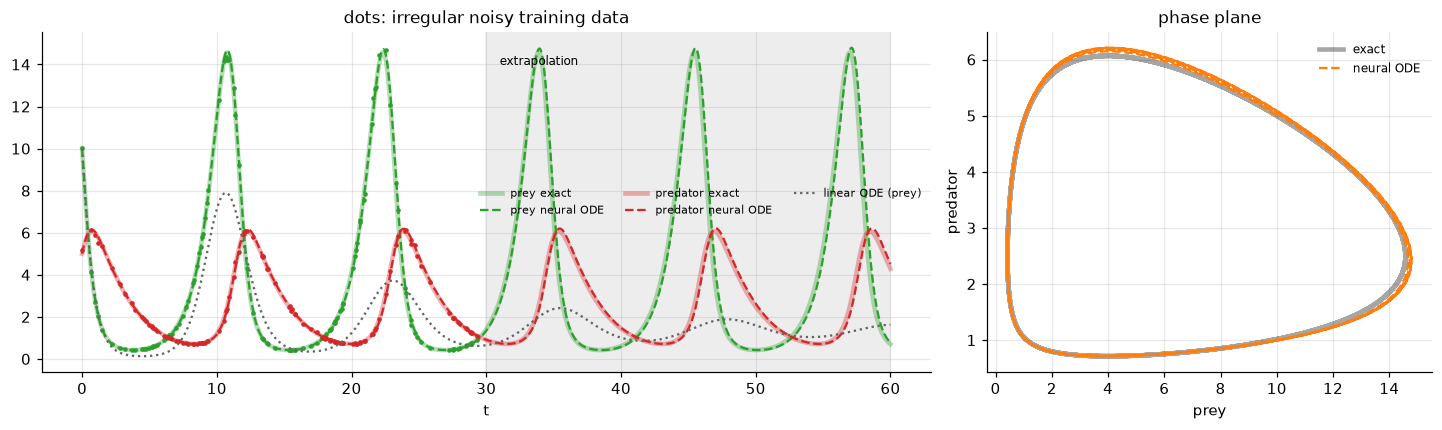

In [8]:
t0 = time.time()
res.update(neural_ode_part(rng, quick))
show_new_figures(t0, LESSON)

In [9]:
_ = save_results(LESSON, res)

In [10]:
res  # all numbers of this run

{'hnn': {'baseline MLP': {'energy_drift_rel': [0.1218018201146023,
    0.10614734493473721,
    0.48384649385444917],
   'traj_err': [0.12912348418081476, 0.18848770033792359, 2.2973505901945708]},
  'HNN': {'energy_drift_rel': [0.021295100024566953,
    0.02010366743584946,
    0.009391843855734706],
   'traj_err': [0.15928084660300598, 0.1229720578413083, 0.01911021377206058]},
  'exact field + RK4 (integrator error only)': {'energy_drift_rel': [9.060781539212209e-06,
    9.99535126067208e-06,
    7.5853839275729925e-06]}},
 'neural_ode': {'neural ODE': {'log_rmse_train_window': 0.023889350045103543,
   'log_rmse_extrapolation': 0.07687508410916284,
   'max_invariant_change': 0.03449228292181883},
  'linear ODE in log-space': {'log_rmse_train_window': 0.6569238552506107,
   'log_rmse_extrapolation': 1.1084200568503177,
   'max_invariant_change': 0.6670603738685112},
  'train_s': 39.12647294998169}}